# LSEG/Gemma hybrid long-leg residual portfolios

**Objective.** Convert Notebook 60's two gross exposure controls into executable, fully costed dollar-neutral portfolios without changing the LSEG/Gemma timing, FinBERT ranking, selected names, selected-long weights, or one-session horizon.

This is a user-authorized **iterative retrospective** strategy translation on an opened 2025–2026 window. It can show whether the existing gross name-selection result has an economically cleaner implementation; it cannot validate alpha or replace the frozen prospective contract. The specification was committed before opening the costed outcomes.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'final_experiments':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.residual_portfolios import build_exposure_residual_targets  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import build_exact_extrema_targets, ledger_rows_to_frame  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import PositionTarget, TargetPortfolio  # noqa: E402

SPEC_PATH = REPO_ROOT / 'final_experiments/frozen_specs/lseg_gemma_hybrid_long_leg_residual_portfolios_v1.json'
AGGREGATE_DIR = REPO_ROOT / 'final_experiments/outputs/13_lseg_44_gemma_robustness'
GEMMA_PATH = AGGREGATE_DIR / 'gemma4_26b_firm_open_aggregators.parquet'
FINBERT_PATH = AGGREGATE_DIR / 'finbert_firm_open_aggregators.parquet'
PRICE_PATH = REPO_ROOT / 'Data/derived/prices/lseg_us_sector_33_8m.csv'
PRICE_MANIFEST_PATH = PRICE_PATH.with_suffix('.manifest.json')
N36_DIR = REPO_ROOT / 'final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit'
N36_DAILY_PATH = N36_DIR / 'capped_hybrid_daily.parquet'
N36_MANIFEST_PATH = N36_DIR / 'manifest.json'
N36_FACTOR_PATH = N36_DIR / 'factor_panel.csv'
N60_DIR = REPO_ROOT / 'final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control'
N60_DAILY_PATH = N60_DIR / 'daily_control_audit.parquet'
N60_MANIFEST_PATH = N60_DIR / 'manifest.json'
OUTPUT_DIR = REPO_ROOT / 'final_experiments/outputs/64_lseg_gemma_hybrid_long_leg_residual_portfolios'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

spec = json.loads(SPEC_PATH.read_text())
assert spec['status'] == 'frozen_before_costed_residual_portfolio_outcomes'
PRIMARY_COST_BPS = float(spec['accounting']['primary_cost_bps_per_side'])
COST_GRID = tuple(float(value) for value in spec['accounting']['cost_curve_bps_per_side'])
INITIAL_NAV = float(spec['accounting']['initial_nav_usd'])
BLOCK_LENGTH = int(spec['inference']['block_length_sessions'])
REPLICATIONS = int(spec['inference']['replications'])
SEED = int(spec['inference']['seed'])
BH_Q = float(spec['inference']['bh_q'])
SINGLE_NAME_CAP = 0.25
TOLERANCE = 1e-12
apply_house_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## Rebuild the unchanged selected-long path

The original 33-company universe, Gemma exact-event schedule/counts, FinBERT ranks, and capped long weights are reconstructed exactly. The two candidate target matrices must reproduce Notebook 60's gross selected-minus-control paths before costs are applied.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
symbols = tuple(sorted(symbol for members in sector_members.values() for symbol in members))
sector_by_symbol = {symbol: sector for sector, members in sector_members.items() for symbol in members}
if len(symbols) != 33 or len(sector_members) != 11 or any(len(members) != 3 for members in sector_members.values()):
    raise ValueError('expected immutable original 33 in eleven three-company sectors')

gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame['session_date'] = pd.to_datetime(frame['session_date']).dt.normalize()
gemma = gemma.loc[gemma['symbol'].isin(symbols)].copy()
finbert = finbert.loc[finbert['symbol'].isin(symbols)].copy()
if not gemma[['session_date', 'symbol']].equals(finbert[['session_date', 'symbol']]):
    raise ValueError('paired scorer panels are not row-aligned')
if gemma.duplicated(['session_date', 'symbol']).any() or finbert['strongest_event'].isna().any():
    raise ValueError('candidate scorer input is invalid')
sessions = pd.DatetimeIndex(sorted(gemma['session_date'].unique()))
if len(sessions) != 167 or set(gemma['symbol'].unique()) != set(symbols):
    raise ValueError('expected 167 sessions and immutable original 33')

prices = pd.read_csv(PRICE_PATH, parse_dates=['session_date'])
prices['session_date'] = pd.to_datetime(prices['session_date']).dt.normalize()
prices = prices.loc[prices['symbol'].isin(symbols)].copy()
price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
assert price_manifest['return_convention'] == 'split-adjusted price returns; dividends not back-adjusted'
assert hashlib.sha256(PRICE_PATH.read_bytes()).hexdigest() == price_manifest['file']['sha256']
open_wide = prices.pivot(index='session_date', columns='symbol', values='open').sort_index().dropna()
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError('signal sessions are not consecutive complete-price sessions')
if locations[-1] + 1 >= len(open_wide):
    raise ValueError('last signal session has no following open')
next_sessions = open_wide.index[locations + 1]
current_open = open_wide.loc[sessions, list(symbols)].to_numpy(dtype=float)
next_open = open_wide.loc[next_sessions, list(symbols)].to_numpy(dtype=float)
return_matrix = next_open / current_open - 1.0
return_rows = [
    OpenToOpenReturn(
        symbol=symbol, session=str(session.date()), next_session=str(next_session.date()),
        value=float(return_matrix[row_index, column_index]),
    )
    for row_index, (session, next_session) in enumerate(zip(sessions, next_sessions, strict=True))
    for column_index, symbol in enumerate(symbols)
]

def rank_map(frame: pd.DataFrame) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(day.sort_values(['strongest_event', 'symbol'], ascending=[False, True], kind='mergesort')['symbol'])
        for session, day in frame.groupby('session_date', sort=True)
    }
    if len(result) != len(sessions) or any(set(row) != set(symbols) for row in result.values()):
        raise ValueError('rank map is incomplete')
    return result

_, target_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
ranks = rank_map(finbert)
selected_long_targets = []
selected_matrix = np.zeros((len(sessions), len(symbols)), dtype=float)
for row_index, row in enumerate(target_audit.itertuples(index=False)):
    n_long, n_short, eligible = int(row.positive_names), int(row.negative_names), bool(row.eligible)
    if eligible:
        ranked = ranks[pd.Timestamp(row.session_date)]
        long_symbols = set(ranked[:n_long])
        short_symbols = set(ranked[-n_short:])
        if not n_long or not n_short or long_symbols & short_symbols:
            raise RuntimeError('invalid hybrid rank selection')
        leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
    else:
        long_symbols, leg_exposure = set(), 0.0
    weights = np.asarray([leg_exposure / n_long if symbol in long_symbols else 0.0 for symbol in symbols])
    selected_matrix[row_index] = weights
    positions = tuple(
        PositionTarget(
            symbol=symbol, action=float(weight > 0), volatility=None,
            raw_weight=float(weight), target_weight=float(weight), exclusion_reason=None,
        )
        for symbol, weight in zip(symbols, weights, strict=True)
    )
    selected_long_targets.append(TargetPortfolio(
        session=str(pd.Timestamp(row.session_date).date()), positions=positions,
        gross_exposure=float(weights.sum()), net_exposure=float(weights.sum()),
        long_exposure=float(weights.sum()), short_exposure=0.0, cash_weight=1.0 - float(weights.sum()),
    ))
selected_long_targets = tuple(selected_long_targets)

target_sets = {}
audit_tables = {}
for mode in ('market', 'sector'):
    target_sets[mode], audit_tables[mode] = build_exposure_residual_targets(
        selected_long_targets, mode=mode, sector_by_symbol=sector_by_symbol if mode == 'sector' else None,
    )

def target_matrix(targets: tuple[TargetPortfolio, ...]) -> np.ndarray:
    return np.asarray([[position.target_weight for position in target.positions] for target in targets], dtype=float)

n60_daily = pd.read_parquet(N60_DAILY_PATH).reset_index(drop=True)
n60_daily['session_date'] = pd.to_datetime(n60_daily['session_date']).dt.normalize()
if not np.array_equal(n60_daily['session_date'].to_numpy(), sessions.to_numpy()):
    raise ValueError('Notebook 60 daily path is not aligned')
selected_gross = np.sum(selected_matrix * return_matrix, axis=1)
selected_identity_error = float(np.max(np.abs(selected_gross - n60_daily['selected_long_gross_contribution'].to_numpy(dtype=float))))
gross_identity_errors = {'selected_long': selected_identity_error}
for mode, column in (('market', 'selected_minus_market'), ('sector', 'selected_minus_same_sector')):
    residual_gross = np.sum(target_matrix(target_sets[mode]) * return_matrix, axis=1)
    gross_identity_errors[mode] = float(np.max(np.abs(residual_gross - n60_daily[column].to_numpy(dtype=float))))
if max(gross_identity_errors.values()) > TOLERANCE:
    raise RuntimeError(f'Notebook 60 gross identity failed: {gross_identity_errors}')
identity = pd.DataFrame([
    {
        'sessions': len(sessions), 'active_sessions': int(target_audit['eligible'].sum()),
        'companies': len(symbols), 'sectors': len(sector_members),
        'selected_long_vs_notebook60_max_error': selected_identity_error,
        'market_residual_vs_notebook60_max_error': gross_identity_errors['market'],
        'sector_residual_vs_notebook60_max_error': gross_identity_errors['sector'],
        'market_max_abs_net_exposure': float(audit_tables['market']['residual_net_exposure'].abs().max()),
        'sector_max_abs_net_exposure': float(audit_tables['sector']['residual_net_exposure'].abs().max()),
        'sector_max_abs_sector_exposure': float(audit_tables['sector']['max_abs_sector_exposure'].max()),
        'licensed_headline_text_loaded': False,
    }
])
display(identity.T)

,0
sessions,167
active_sessions,70
companies,33
sectors,11
selected_long_vs_notebook60_max_error,0.000000
market_residual_vs_notebook60_max_error,0.000000
sector_residual_vs_notebook60_max_error,0.000000
market_max_abs_net_exposure,0.000000
sector_max_abs_net_exposure,0.000000
sector_max_abs_sector_exposure,0.000000


## Drift-aware costs and fixed comparison

Signal and hedge weights are netted by name before orders. The validated ledger charges every rebalance and terminal liquidation. No candidate is scaled to consume unused gross capacity.

In [3]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame['final_liquidation']]
    intervals = frame.loc[~frame['final_liquidation']].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError('expected one terminal liquidation')
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, 'net_return'] = (1.0 + intervals.loc[last, 'net_return']) * (1.0 + final['net_return']) - 1.0
    intervals.loc[last, 'turnover'] += final['turnover']
    intervals.loc[last, 'cost'] += final['cost']
    intervals.loc[last, 'end_nav'] = final['end_nav']
    return intervals

def run_targets(targets: tuple[TargetPortfolio, ...], cost_bps: float) -> pd.DataFrame:
    rows = run_open_to_open_ledger(
        targets, return_rows, cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV, force_final_liquidation=True,
    )
    return fold_final_liquidation(ledger_rows_to_frame(rows))

def summarize(daily: pd.DataFrame, cost_bps: float) -> dict[str, float | int]:
    gross = daily['gross_return'].to_numpy(dtype=float)
    net = daily['net_return'].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    equity_with_start = np.r_[1.0, equity]
    turnover = float(daily['turnover'].sum())
    return {
        'n_sessions': len(daily), 'active_sessions': int(daily['gross_exposure'].gt(0).sum()),
        'mean_gross': float(gross.mean()), 'mean_net': float(net.mean()),
        'sharpe_gross': float(annualized_sharpe(pd.Series(gross))),
        'sharpe_net': float(annualized_sharpe(pd.Series(net))),
        'ann_vol_net': float(np.std(net, ddof=1) * np.sqrt(252)),
        'total_return_gross': float(np.prod(1.0 + gross) - 1.0),
        'total_return_net': float(equity[-1] - 1.0),
        'max_drawdown': float(np.min(equity_with_start / np.maximum.accumulate(equity_with_start) - 1.0)),
        'mean_turnover': float(turnover / len(daily)), 'total_turnover': turnover,
        'breakeven_bps_per_side': float(10_000.0 * gross.sum() / turnover),
        'cost_bps_per_side': cost_bps,
    }

daily_paths = {mode: run_targets(targets, PRIMARY_COST_BPS) for mode, targets in target_sets.items()}
n36_daily = pd.read_parquet(N36_DAILY_PATH).reset_index(drop=True)
n36_daily['session_date'] = pd.to_datetime(n36_daily['session_date']).dt.normalize()
if not np.array_equal(n36_daily['session_date'].to_numpy(), sessions.to_numpy()):
    raise ValueError('Notebook 36 daily path is not aligned')
n36_manifest = json.loads(N36_MANIFEST_PATH.read_text())
n36_reference = n36_manifest['result']
if not np.isclose(n36_daily['net_return'].mean(), n36_reference['mean_net'], atol=1e-12):
    raise RuntimeError('Notebook 36 reference path does not reproduce its manifest')
for mode, column in (('market', 'selected_minus_market'), ('sector', 'selected_minus_same_sector')):
    error = float(np.max(np.abs(daily_paths[mode]['gross_return'] - n60_daily[column])))
    if error > TOLERANCE:
        raise RuntimeError(f'{mode} ledger gross return does not reproduce Notebook 60')

result_rows = [{'strategy': 'notebook36_incumbent', **n36_reference}]
for mode, daily in daily_paths.items():
    result_rows.append({'strategy': f'{mode}_residual', **summarize(daily, PRIMARY_COST_BPS)})
strategy_results = pd.DataFrame(result_rows)
cost_curve_rows = []
for mode, targets in target_sets.items():
    for cost_bps in COST_GRID:
        cost_curve_rows.append({'strategy': f'{mode}_residual', **summarize(run_targets(targets, cost_bps), cost_bps)})
cost_curve = pd.DataFrame(cost_curve_rows)
display(strategy_results)
display(cost_curve[['strategy', 'cost_bps_per_side', 'sharpe_net', 'total_return_net', 'breakeven_bps_per_side']])

,strategy,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,breakeven_bps_per_side,cost_bps_per_side
0,notebook36_incumbent,167,70,0.001127,0.000680,3.699940,2.271209,0.075473,0.204584,0.118176,-0.029025,0.446484,74.562862,25.235033,10.000000
1,market_residual,167,70,0.000836,0.000506,3.787383,2.331917,0.054638,0.148630,0.087019,-0.018507,0.330557,55.203097,25.295459,10.000000
2,sector_residual,167,70,0.000366,0.000096,3.076815,0.818334,0.029479,0.062737,0.015825,-0.016535,0.270464,45.167457,13.539455,10.000000


,strategy,cost_bps_per_side,sharpe_net,total_return_net,breakeven_bps_per_side
0,market_residual,0.000000,3.787383,0.148630,25.302835
1,market_residual,5.000000,3.069312,0.117410,25.299151
2,market_residual,10.000000,2.331917,0.087019,25.295459
3,market_residual,25.000000,0.043898,0.000617,25.284277
4,market_residual,50.000000,-3.742897,-0.128691,25.265333
5,sector_residual,0.000000,3.076815,0.062737,13.543107
6,sector_residual,5.000000,1.962563,0.039023,13.541281
7,sector_residual,10.000000,0.818334,0.015825,13.539455
8,sector_residual,25.000000,-2.616148,-0.050777,13.533971
9,sector_residual,50.000000,-7.437306,-0.152427,13.524810


## Frozen inference, factor control, and classification

The primary family contains both new portfolios versus cash and versus the unchanged Notebook 36 incumbent. A separate two-test family evaluates after-cost sector-spanning intercepts. No best arm is selected outside these declared gates.

In [4]:
comparison_specs = [
    ('market_residual_minus_cash', daily_paths['market'], None),
    ('sector_residual_minus_cash', daily_paths['sector'], None),
    ('market_residual_minus_notebook36_incumbent', daily_paths['market'], n36_daily),
    ('sector_residual_minus_notebook36_incumbent', daily_paths['sector'], n36_daily),
]
inference_rows = []
for comparison, candidate, reference in comparison_specs:
    if reference is None:
        reference = candidate[['session_date']].copy()
        reference['net_return'] = 0.0
    stats = paired_block_bootstrap_difference(
        candidate[['session_date', 'net_return']], reference[['session_date', 'net_return']],
        value_col='net_return', block_length=BLOCK_LENGTH, replications=REPLICATIONS, seed=SEED,
    )
    inference_rows.append({'comparison': comparison, **stats})
primary_inference = pd.DataFrame(inference_rows)
primary_inference['mean_difference_bps_session'] = primary_inference['mean_difference'] * 10_000
primary_inference['ci_low_bps_session'] = primary_inference['ci_low'] * 10_000
primary_inference['ci_high_bps_session'] = primary_inference['ci_high'] * 10_000
reject, q_values, _, _ = multipletests(primary_inference['p_two_sided'], alpha=BH_Q, method='fdr_bh')
primary_inference['bh_q_value'] = q_values
primary_inference['bh_reject'] = reject
primary_inference['positive_gate'] = primary_inference['mean_difference'].gt(0) & primary_inference['bh_reject']

factor_panel = pd.read_csv(N36_FACTOR_PATH, parse_dates=['session_date'])
factor_panel['session_date'] = pd.to_datetime(factor_panel['session_date']).dt.normalize()
factor_columns = ['equal_weight_market', *[column for column in factor_panel if column.startswith('spread_')]]
factor_rows = []
for mode, daily in daily_paths.items():
    regression = daily[['session_date', 'net_return']].merge(factor_panel, on='session_date', validate='1:1')
    design = sm.add_constant(regression[factor_columns], has_constant='add')
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
        raise RuntimeError(f'factor design is rank deficient for {mode}')
    fit = sm.OLS(regression['net_return'], design).fit(cov_type='HAC', cov_kwds={'maxlags': BLOCK_LENGTH, 'use_correction': True})
    interval = fit.conf_int(alpha=0.05).loc['const']
    factor_rows.append({
        'strategy': f'{mode}_residual', 'n_sessions': int(fit.nobs),
        'alpha_bps_session': float(fit.params['const'] * 10_000),
        'alpha_ci_low_bps_session': float(interval.iloc[0] * 10_000),
        'alpha_ci_high_bps_session': float(interval.iloc[1] * 10_000),
        'alpha_t_hac5': float(fit.tvalues['const']), 'alpha_p_two_sided_hac5': float(fit.pvalues['const']),
        'r_squared': float(fit.rsquared), 'market_beta': float(fit.params['equal_weight_market']),
    })
factor_models = pd.DataFrame(factor_rows)
factor_reject, factor_q, _, _ = multipletests(factor_models['alpha_p_two_sided_hac5'], alpha=BH_Q, method='fdr_bh')
factor_models['bh_q_value'] = factor_q
factor_models['bh_reject'] = factor_reject
factor_models['positive_gate'] = factor_models['alpha_bps_session'].gt(0) & factor_models['bh_reject']

split = (len(sessions) + 1) // 2
temporal_rows = []
for mode, daily in daily_paths.items():
    for period, values in (('first_half', daily['net_return'].iloc[:split]), ('second_half', daily['net_return'].iloc[split:])):
        temporal_rows.append({
            'strategy': f'{mode}_residual', 'period': period, 'sessions': len(values),
            'mean_net_bps_session': float(values.mean() * 10_000),
            'sharpe_net': float(annualized_sharpe(values)), 'total_return_net': float(np.prod(1.0 + values) - 1.0),
        })
temporal_halves = pd.DataFrame(temporal_rows)

primary_index = primary_inference.set_index('comparison')
factor_index = factor_models.set_index('strategy')
result_index = strategy_results.set_index('strategy')
temporal_index = temporal_halves.set_index(['strategy', 'period'])
classification_rows = []
for mode in ('market', 'sector'):
    strategy = f'{mode}_residual'
    cash_pass = bool(primary_index.loc[f'{strategy}_minus_cash', 'positive_gate'])
    improvement_pass = bool(primary_index.loc[f'{strategy}_minus_notebook36_incumbent', 'positive_gate'])
    factor_pass = bool(factor_index.loc[strategy, 'positive_gate'])
    both_halves_positive = bool(
        temporal_index.loc[(strategy, 'first_half'), 'mean_net_bps_session'] > 0
        and temporal_index.loc[(strategy, 'second_half'), 'mean_net_bps_session'] > 0
    )
    break_even_pass = bool(result_index.loc[strategy, 'breakeven_bps_per_side'] > PRIMARY_COST_BPS)
    active_pass = bool(result_index.loc[strategy, 'active_sessions'] >= 60)
    max_weight = float(audit_tables[mode]['max_abs_name_weight'].max())
    weight_pass = bool(max_weight <= SINGLE_NAME_CAP + TOLERANCE)
    if cash_pass and improvement_pass and factor_pass and both_halves_positive and break_even_pass and active_pass and weight_pass:
        result_class = 'retrospective_improvement'
    elif cash_pass and both_halves_positive:
        result_class = 'costed_positive_not_improved'
    else:
        result_class = 'nonviable'
    classification_rows.append({
        'strategy': strategy, 'classification': result_class, 'cash_gate': cash_pass,
        'incumbent_improvement_gate': improvement_pass, 'factor_gate': factor_pass,
        'both_half_means_positive': both_halves_positive, 'breakeven_gate': break_even_pass,
        'active_session_gate': active_pass, 'single_name_cap_gate': weight_pass, 'maximum_abs_name_weight': max_weight,
    })
classifications = pd.DataFrame(classification_rows)
primary_display_columns = [
    'comparison', 'mean_difference_bps_session', 'ci_low_bps_session',
    'ci_high_bps_session', 'p_two_sided', 'bh_q_value', 'positive_gate',
]
display(primary_inference[primary_display_columns])
display(factor_models)
display(temporal_halves)
display(classifications)

,comparison,mean_difference_bps_session,ci_low_bps_session,ci_high_bps_session,p_two_sided,bh_q_value,positive_gate
0,market_residual_minus_cash,5.056028,0.288356,10.397935,0.048300,0.096600,False
1,sector_residual_minus_cash,0.957295,-1.689038,3.893467,0.496900,0.496900,False
2,market_residual_minus_notebook36_incumbent,-1.746173,-5.647259,1.991006,0.378900,0.496900,False
3,sector_residual_minus_notebook36_incumbent,-5.844907,-10.988350,-0.857497,0.022900,0.091600,False


,strategy,n_sessions,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta,bh_q_value,bh_reject,positive_gate
0,market_residual,167,4.233512,0.028279,8.438746,1.973144,0.048479,0.169012,0.021646,0.096958,False,False
1,sector_residual,167,0.743967,-1.747936,3.235869,0.585154,0.558444,0.103264,-0.016134,0.558444,False,False


,strategy,period,sessions,mean_net_bps_session,sharpe_net,total_return_net
0,market_residual,first_half,84,8.353974,3.303192,0.071954
1,market_residual,second_half,83,1.718348,0.999851,0.014054
2,sector_residual,first_half,84,3.624569,2.869722,0.030738
3,sector_residual,second_half,83,-1.742115,-1.663029,-0.014468


,strategy,classification,cash_gate,incumbent_improvement_gate,factor_gate,both_half_means_positive,breakeven_gate,active_session_gate,single_name_cap_gate,maximum_abs_name_weight
0,market_residual,nonviable,False,False,False,True,True,True,True,0.242424
1,sector_residual,nonviable,False,False,False,False,True,True,True,0.166667


## Results figure

findfont: Failed to find font weight medium, now using 400.


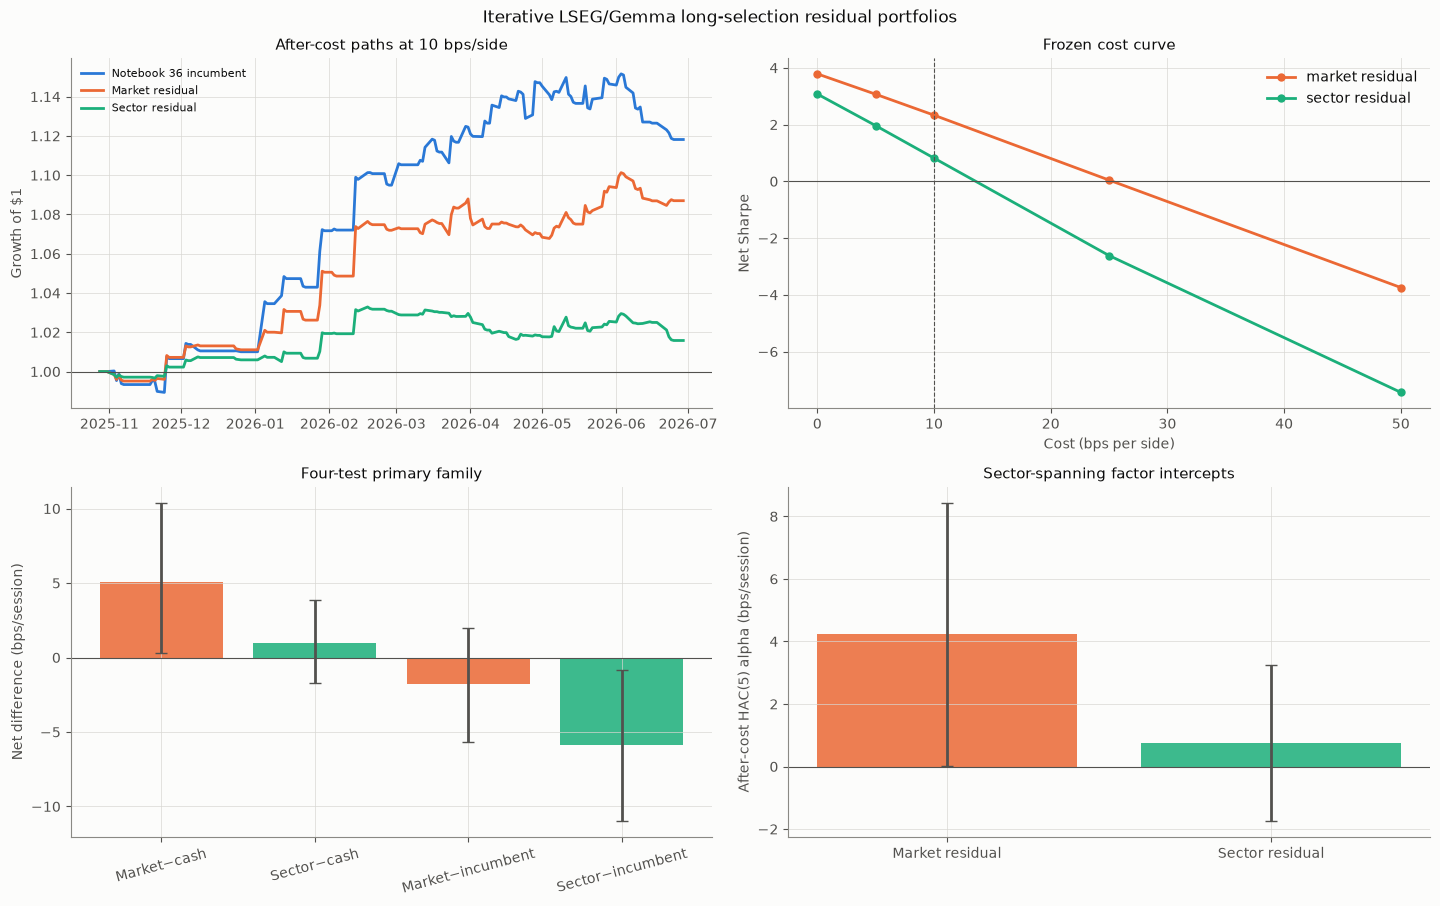

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.2))
for label, daily, color in (
    ('Notebook 36 incumbent', n36_daily, CATEGORICAL[0]),
    ('Market residual', daily_paths['market'], CATEGORICAL[1]),
    ('Sector residual', daily_paths['sector'], CATEGORICAL[2]),
):
    axes[0, 0].plot(daily['return_end_date'], np.cumprod(1.0 + daily['net_return']), lw=2.0, label=label, color=color)
axes[0, 0].axhline(1.0, color=INK['reference'], lw=0.8)
axes[0, 0].set_ylabel('Growth of $1')
axes[0, 0].set_title('After-cost paths at 10 bps/side')
axes[0, 0].legend(frameon=False, fontsize=8)

for mode, color in (('market_residual', CATEGORICAL[1]), ('sector_residual', CATEGORICAL[2])):
    curve = cost_curve.loc[cost_curve['strategy'].eq(mode)]
    axes[0, 1].plot(curve['cost_bps_per_side'], curve['sharpe_net'], marker='o', lw=2.0, label=mode.replace('_', ' '), color=color)
axes[0, 1].axhline(0.0, color=INK['reference'], lw=0.8)
axes[0, 1].axvline(PRIMARY_COST_BPS, color=INK['reference'], lw=0.8, ls='--')
axes[0, 1].set_xlabel('Cost (bps per side)')
axes[0, 1].set_ylabel('Net Sharpe')
axes[0, 1].set_title('Frozen cost curve')
axes[0, 1].legend(frameon=False)

x = np.arange(len(primary_inference))
means = primary_inference['mean_difference_bps_session'].to_numpy(dtype=float)
lower = means - primary_inference['ci_low_bps_session'].to_numpy(dtype=float)
upper = primary_inference['ci_high_bps_session'].to_numpy(dtype=float) - means
axes[1, 0].bar(x, means, color=[CATEGORICAL[1], CATEGORICAL[2], CATEGORICAL[1], CATEGORICAL[2]], alpha=0.85)
axes[1, 0].errorbar(x, means, yerr=np.vstack([lower, upper]), fmt='none', color=INK['reference'], capsize=4)
axes[1, 0].axhline(0.0, color=INK['reference'], lw=0.8)
axes[1, 0].set_xticks(x, ['Market−cash', 'Sector−cash', 'Market−incumbent', 'Sector−incumbent'], rotation=15)
axes[1, 0].set_ylabel('Net difference (bps/session)')
axes[1, 0].set_title('Four-test primary family')

factor_x = np.arange(len(factor_models))
factor_mean = factor_models['alpha_bps_session'].to_numpy(dtype=float)
factor_lower = factor_mean - factor_models['alpha_ci_low_bps_session'].to_numpy(dtype=float)
factor_upper = factor_models['alpha_ci_high_bps_session'].to_numpy(dtype=float) - factor_mean
axes[1, 1].bar(factor_x, factor_mean, color=[CATEGORICAL[1], CATEGORICAL[2]], alpha=0.85)
axes[1, 1].errorbar(factor_x, factor_mean, yerr=np.vstack([factor_lower, factor_upper]), fmt='none', color=INK['reference'], capsize=4)
axes[1, 1].axhline(0.0, color=INK['reference'], lw=0.8)
axes[1, 1].set_xticks(factor_x, ['Market residual', 'Sector residual'])
axes[1, 1].set_ylabel('After-cost HAC(5) alpha (bps/session)')
axes[1, 1].set_title('Sector-spanning factor intercepts')
fig.suptitle('Iterative LSEG/Gemma long-selection residual portfolios')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'residual_portfolio_results.png', dpi=180, bbox_inches='tight')
plt.show()

## Persist aggregate evidence and enforce the claim boundary

In [6]:
identity.to_csv(OUTPUT_DIR / 'identity.csv', index=False)
strategy_results.to_csv(OUTPUT_DIR / 'strategy_results.csv', index=False)
cost_curve.to_csv(OUTPUT_DIR / 'cost_curve.csv', index=False)
primary_inference.to_csv(OUTPUT_DIR / 'primary_inference.csv', index=False)
factor_models.to_csv(OUTPUT_DIR / 'factor_models.csv', index=False)
temporal_halves.to_csv(OUTPUT_DIR / 'temporal_halves.csv', index=False)
classifications.to_csv(OUTPUT_DIR / 'classifications.csv', index=False)
for mode, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f'{mode}_residual_daily.parquet', index=False)
    audit_tables[mode].to_parquet(OUTPUT_DIR / f'{mode}_target_audit.parquet', index=False)

try:
    git_commit = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=REPO_ROOT, check=True, capture_output=True, text=True).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None
decision = {
    'classifications': dict(zip(classifications['strategy'], classifications['classification'], strict=True)),
    'any_retrospective_improvement': bool(classifications['classification'].eq('retrospective_improvement').any()),
    'best_new_strategy_by_descriptive_net_sharpe': str(
        strategy_results.loc[strategy_results['strategy'].ne('notebook36_incumbent')]
        .sort_values('sharpe_net', ascending=False).iloc[0]['strategy']
    ),
    'incumbent_net_sharpe': float(result_index.loc['notebook36_incumbent', 'sharpe_net']),
    'market_residual_net_sharpe': float(result_index.loc['market_residual', 'sharpe_net']),
    'sector_residual_net_sharpe': float(result_index.loc['sector_residual', 'sharpe_net']),
    'prospective_contract_changed': False, 'validated_alpha': False, 'deployment_qualified': False,
}
manifest = {
    'status': 'ITERATIVE_RETROSPECTIVE_COSTED_LONG_SELECTION_RESIDUAL_PORTFOLIOS',
    'notebook': '64_lseg_gemma_hybrid_long_leg_residual_portfolios.ipynb',
    'git_commit_at_execution': git_commit,
    'frozen_spec_sha256': hashlib.sha256(SPEC_PATH.read_bytes()).hexdigest(),
    'specification': spec,
    'inputs': {
        'gemma_aggregate_panel': str(GEMMA_PATH.relative_to(REPO_ROOT)),
        'finbert_aggregate_panel': str(FINBERT_PATH.relative_to(REPO_ROOT)),
        'price_path': str(PRICE_PATH.relative_to(REPO_ROOT)),
        'notebook36_manifest_sha256': hashlib.sha256(N36_MANIFEST_PATH.read_bytes()).hexdigest(),
        'notebook60_manifest_sha256': hashlib.sha256(N60_MANIFEST_PATH.read_bytes()).hexdigest(),
        'licensed_headline_text_loaded': False, 'source_regimes_pooled': False,
    },
    'identity': json.loads(identity.to_json(orient='records'))[0],
    'strategy_results': json.loads(strategy_results.to_json(orient='records')),
    'cost_curve': json.loads(cost_curve.to_json(orient='records')),
    'primary_inference': json.loads(primary_inference.to_json(orient='records')),
    'factor_models': json.loads(factor_models.to_json(orient='records')),
    'temporal_halves': json.loads(temporal_halves.to_json(orient='records')),
    'classifications': json.loads(classifications.to_json(orient='records')),
    'decision': decision,
    'limitations': [
        'The long-leg focus, two controls, and historical window were selected after earlier outcomes were opened.',
        'This is a costed implementation of an existing diagnostic, not independent validation or a new scorer test.',
        'Daily bars omit bid-ask spreads, auction slippage, financing, borrow availability and fees, taxes, and market impact.',
        'The internal equal-weight market and sector hedges are research baskets, not directly quoted tradeable instruments.',
        'Split-adjusted price returns exclude dividends.',
        'No result may alter the frozen prospective strategy; genuinely new dates remain the alpha test.',
    ],
}
(OUTPUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')

market_row = result_index.loc['market_residual']
sector_row = result_index.loc['sector_residual']
display(Markdown(
    '### Decision\n\n'
    f"- Market residual: net Sharpe **{market_row['sharpe_net']:.3f}**, "
    f"net return **{market_row['total_return_net']:+.2%}**, "
    f"break-even **{market_row['breakeven_bps_per_side']:.2f} bps/side**, "
    f"class **{decision['classifications']['market_residual']}**.\n"
    f"- Sector residual: net Sharpe **{sector_row['sharpe_net']:.3f}**, "
    f"net return **{sector_row['total_return_net']:+.2%}**, "
    f"break-even **{sector_row['breakeven_bps_per_side']:.2f} bps/side**, "
    f"class **{decision['classifications']['sector_residual']}**.\n"
    f"- Incumbent Notebook 36 net Sharpe remains **{decision['incumbent_net_sharpe']:.3f}**. "
    f"Any retrospective improvement gate: **{decision['any_retrospective_improvement']}**.\n"
    '- This opened-window result does not validate alpha, qualify deployment, or change the prospective contract.'
))
print(json.dumps(decision, indent=2))

### Decision

- Market residual: net Sharpe **2.332**, net return **+8.70%**, break-even **25.30 bps/side**, class **nonviable**.
- Sector residual: net Sharpe **0.818**, net return **+1.58%**, break-even **13.54 bps/side**, class **nonviable**.
- Incumbent Notebook 36 net Sharpe remains **2.271**. Any retrospective improvement gate: **False**.
- This opened-window result does not validate alpha, qualify deployment, or change the prospective contract.

{
  "classifications": {
    "market_residual": "nonviable",
    "sector_residual": "nonviable"
  },
  "any_retrospective_improvement": false,
  "best_new_strategy_by_descriptive_net_sharpe": "market_residual",
  "incumbent_net_sharpe": 2.2712085877,
  "market_residual_net_sharpe": 2.3319173710495282,
  "sector_residual_net_sharpe": 0.8183341912052225,
  "prospective_contract_changed": false,
  "validated_alpha": false,
  "deployment_qualified": false
}


## Next step

If neither frozen arm passes, close mechanical hedge replacement on this historical window. If one passes, retain it only as a retrospective comparator and examine capacity once—without replacing the unchanged Notebook 36 prospective replay. Human construct validation and genuinely new dates remain the only routes to stronger evidence.